In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings('ignore')

colormap = sns.color_palette("Blues")
sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({'font.size': 22})
sns.set(font_scale=2.4)

In [6]:
AGENTS = [
    "meta-llama/Meta-Llama-3-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.2",
]
AGENTS_CLEAN_NAMES = ["Llama-3-8B", "Mistral-7B"]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))

LOGS_ROOT = "../../../.logs/small_models"

#### Utils

In [7]:
def load_games_from_dir(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def resource_value(res):
    return sum(res["_value"].values())


def replace_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df

## Game Completion Rates

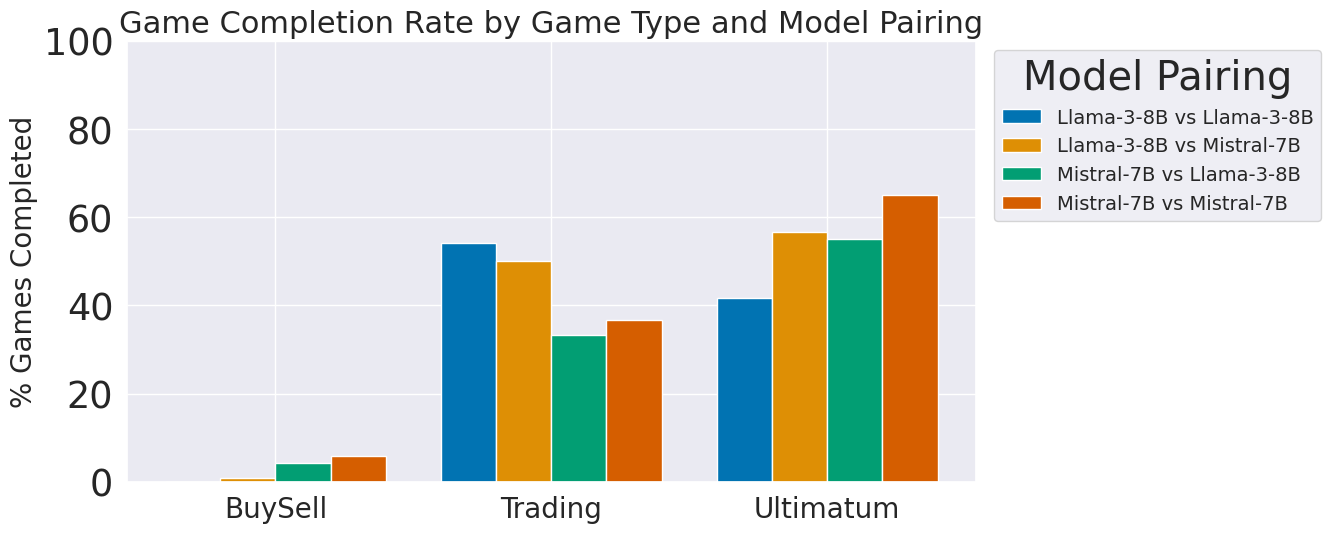

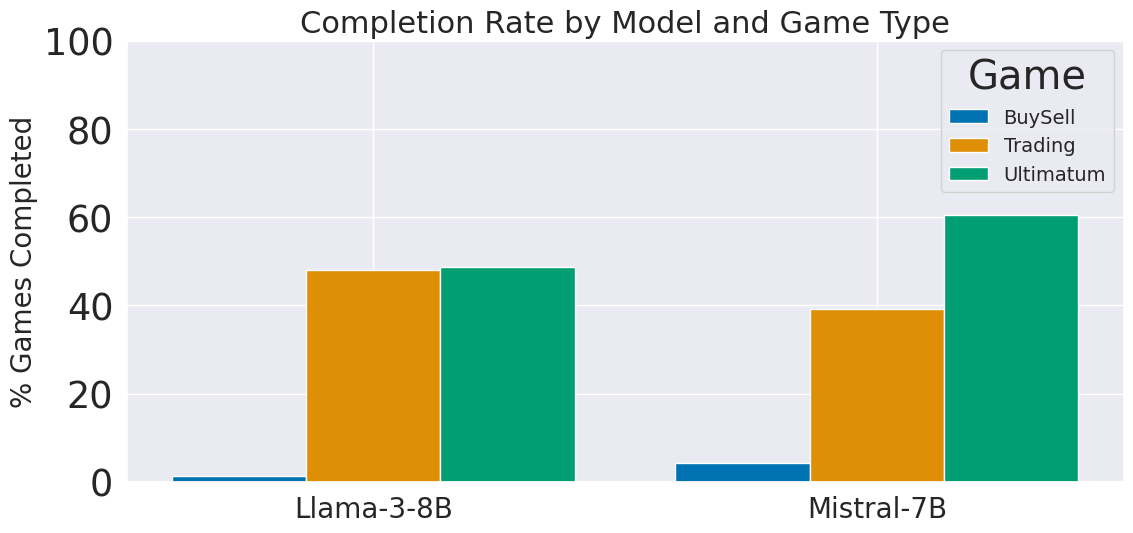

In [8]:
def load_completion_stats(log_dirs):
    rows = []
    for game_name, log_dir in log_dirs.items():
        for root, dirs, files in os.walk(log_dir):
            if "game_state.json" not in files:
                continue
            path = os.path.join(root, "game_state.json")
            try:
                with open(path) as f:
                    data = json.load(f)
                players = data["players"]
                last = data["game_state"][-1]
                completed = last.get("current_iteration") == "END"
                rows.append({
                    "game": game_name,
                    "model_1": players[0].get("model_id", players[0].get("model", "unknown")),
                    "model_2": players[1].get("model_id", players[1].get("model", "unknown")),
                    "completed": completed,
                })
            except Exception:
                pass
    return pd.DataFrame(rows)


log_dirs = {
    "Trading": os.path.join(LOGS_ROOT, "section_one/trading_section_one"),
    "Ultimatum": os.path.join(LOGS_ROOT, "section_one/ultimatum_section_one"),
    "BuySell": os.path.join(LOGS_ROOT, "section_one/buysell_section_one"),
}

df_raw = load_completion_stats(log_dirs)
df_raw["model_1"] = df_raw["model_1"].replace(rename_dict)
df_raw["model_2"] = df_raw["model_2"].replace(rename_dict)
df_raw["pairing"] = df_raw["model_1"] + " vs " + df_raw["model_2"]

agg = df_raw.groupby(["game", "pairing"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = agg["game"].unique()
pairings = sorted(agg["pairing"].unique())
x = np.arange(len(games))
width = 0.8 / len(pairings)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette("colorblind", len(pairings))

for i, pairing in enumerate(pairings):
    sub = agg[agg["pairing"] == pairing].set_index("game")
    vals = [sub.loc[g, "pct"] if g in sub.index else 0 for g in games]
    ax.bar(x + i * width, vals, width, label=pairing, color=colors[i])

ax.set_xticks(x + width * (len(pairings) - 1) / 2)
ax.set_xticklabels(games, fontsize=20)
ax.set_ylabel("% Games Completed", fontsize=20)
ax.set_title("Game Completion Rate by Game Type and Model Pairing", fontsize=22)
ax.set_ylim(0, 100)
ax.legend(title="Model Pairing", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=14)
fig.tight_layout()
#plt.savefig("../../figures/small_completion_rate.pdf", bbox_inches="tight")
plt.show()

# --- Per-model completion rate ---
df_m1 = df_raw[["game", "model_1", "completed"]].rename(columns={"model_1": "model"})
df_m2 = df_raw[["game", "model_2", "completed"]].rename(columns={"model_2": "model"})
agg_model = (
    pd.concat([df_m1, df_m2])
    .groupby(["game", "model"])
    .agg(total=("completed", "count"), completed=("completed", "sum"))
    .reset_index()
)
agg_model["pct"] = agg_model["completed"] / agg_model["total"] * 100

games_list = sorted(agg_model["game"].unique())
models_list = AGENTS_CLEAN_NAMES
x2 = np.arange(len(models_list))
width2 = 0.8 / len(games_list)

fig2, ax2 = plt.subplots(figsize=(12, 6))
game_colors = sns.color_palette("colorblind", len(games_list))

for i, game in enumerate(games_list):
    sub = agg_model[agg_model["game"] == game].set_index("model")
    vals = [sub.loc[m, "pct"] if m in sub.index else 0 for m in models_list]
    ax2.bar(x2 + i * width2, vals, width2, label=game, color=game_colors[i])

ax2.set_xticks(x2 + width2 * (len(games_list) - 1) / 2)
ax2.set_xticklabels(models_list, fontsize=20)
ax2.set_ylabel("% Games Completed", fontsize=20)
ax2.set_title("Completion Rate by Model and Game Type", fontsize=22)
ax2.set_ylim(0, 100)
ax2.legend(title="Game", fontsize=14)
fig2.tight_layout()
#plt.savefig("../../figures/small_completion_rate_by_model.pdf", bbox_inches="tight")
plt.show()


## Trading

In [9]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/trading_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_names(pd.DataFrame(rows))
trading_df.head()

Found 209 completed games in ../../../.logs/small_models/section_one/trading_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,TradingGame,Llama-3-8B,Llama-3-8B,1,-1
1,TradingGame,Llama-3-8B,Llama-3-8B,6,-6
2,TradingGame,Llama-3-8B,Llama-3-8B,11,-11
3,TradingGame,Llama-3-8B,Llama-3-8B,-11,11
4,TradingGame,Llama-3-8B,Llama-3-8B,3,-3


In [10]:
def trading_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    agg["win_1"] = agg["win_1"] / (agg["win_1"] + agg["win_2"])
    agg["win_2"] = agg["win_2"] / (agg["win_1"] + agg["win_2"])
    return agg


aggregated = trading_aggregation(trading_df)

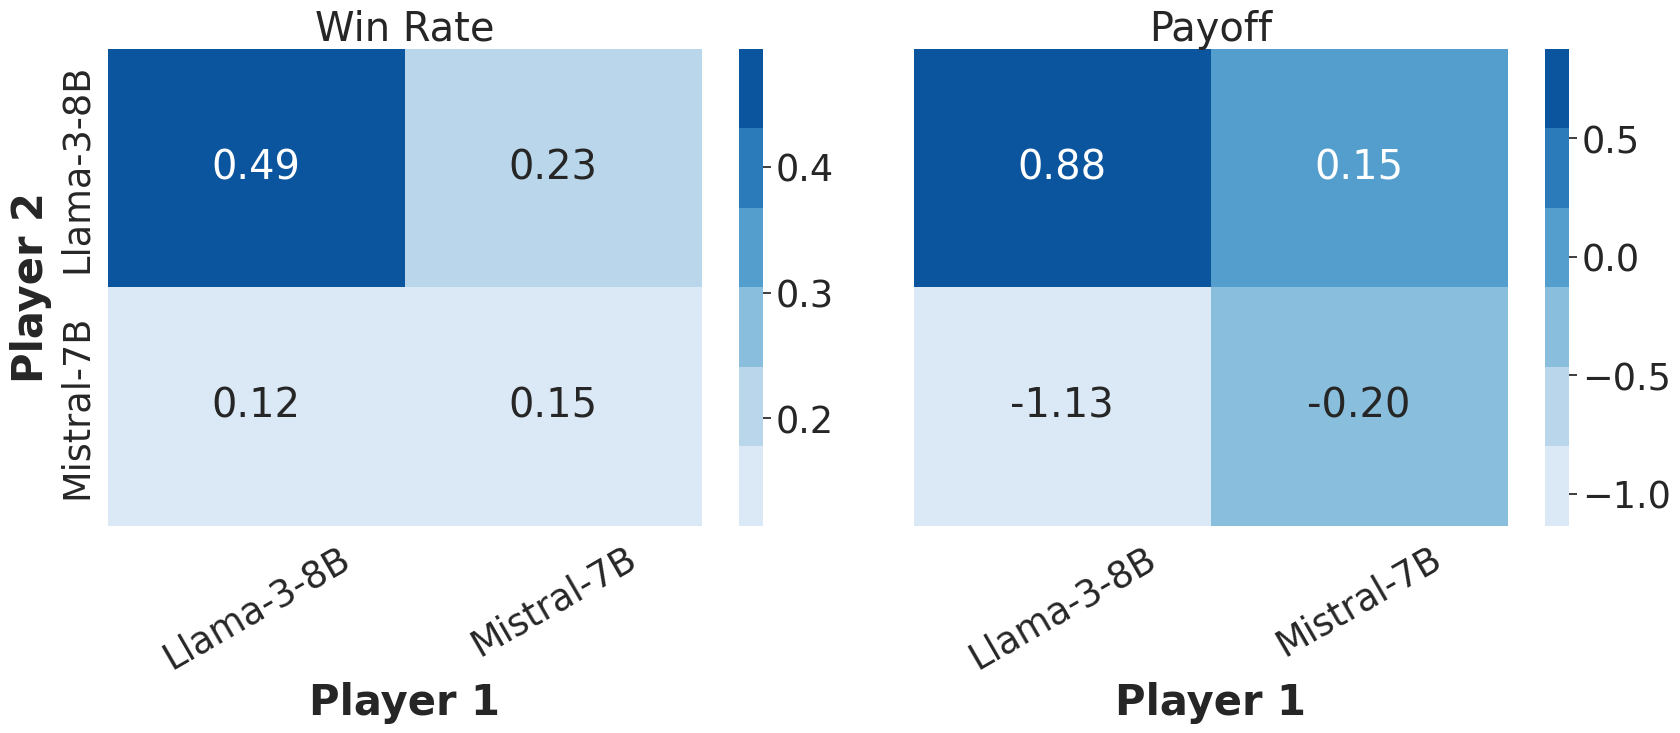

In [11]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)
fig.tight_layout()

# Win Rate heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="win_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_ylabel("Player 2", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p1.set_title("Win Rate")
p1.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)

# Payoff heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="resource_delta_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p2.set_title("Payoff")
p2.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)
p2.set_yticklabels(labels=[])

fig.tight_layout()
#plt.savefig("../../figures/oss_trading.pdf", bbox_inches="tight")
plt.show()

## Ultimatum

In [12]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/ultimatum_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_names(pd.DataFrame(rows))

# P1 starts with $100, adjust so resource_delta_1 = amount P1 keeps
ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
# If delta+100 == 100 (no deal happened), set to 0
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

ultimatum_df.head()

Found 262 completed games in ../../../.logs/small_models/section_one/ultimatum_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,MultiTurnUltimatumGame,Llama-3-8B,Llama-3-8B,0,0
1,MultiTurnUltimatumGame,Llama-3-8B,Llama-3-8B,75,25
2,MultiTurnUltimatumGame,Llama-3-8B,Llama-3-8B,0,0
3,MultiTurnUltimatumGame,Llama-3-8B,Llama-3-8B,0,0
4,MultiTurnUltimatumGame,Llama-3-8B,Llama-3-8B,96,4


In [13]:
def ultimatum_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    agg["win_1"] = agg["win_1"] / (agg["win_1"] + agg["win_2"])
    agg["win_2"] = agg["win_2"] / (agg["win_1"] + agg["win_2"])
    return agg


aggregated = ultimatum_aggregation(ultimatum_df)

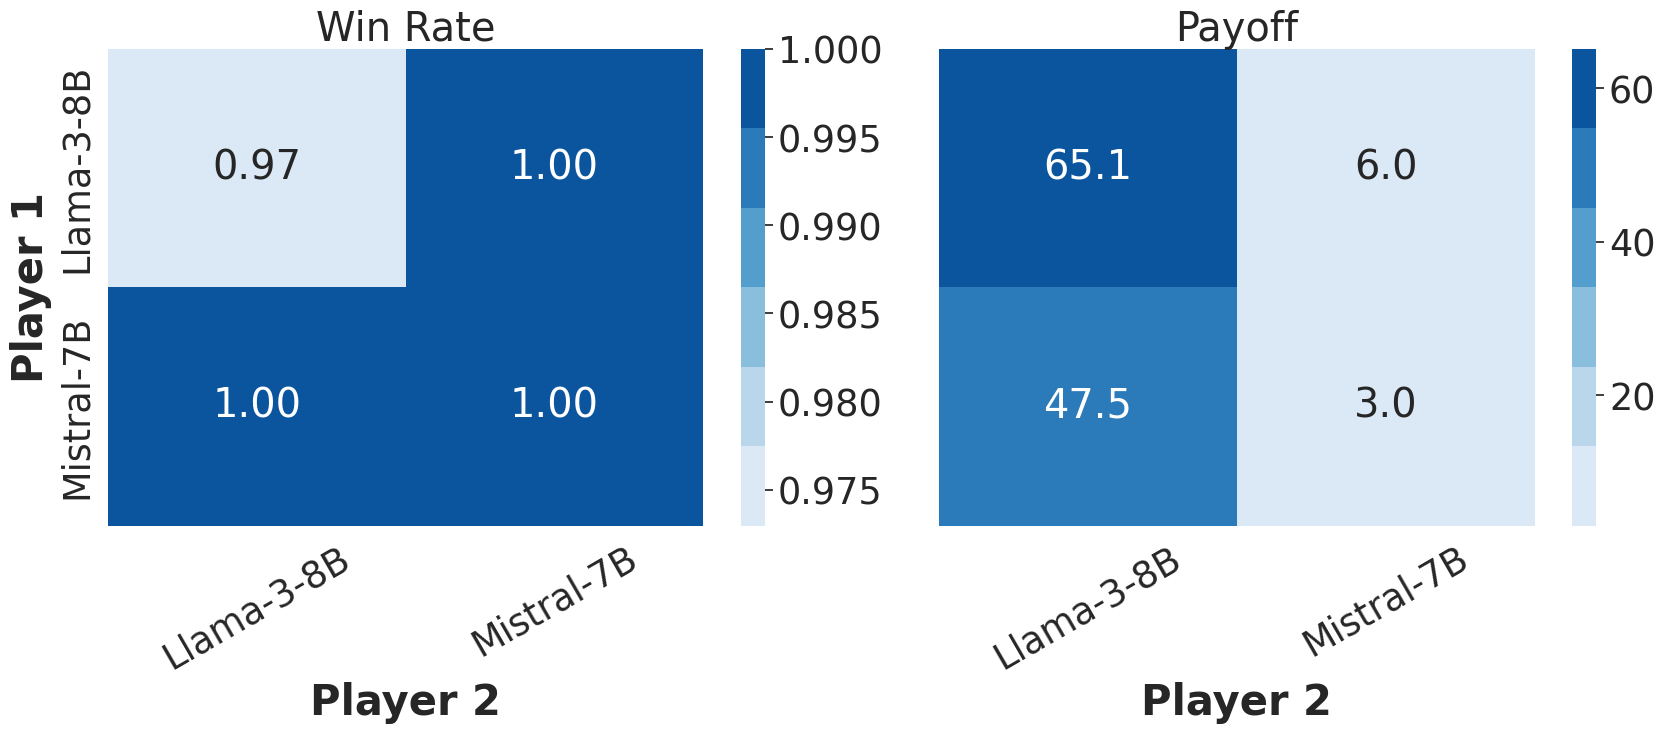

In [14]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)
fig.tight_layout()

# Win Rate heatmap
local = aggregated.pivot(index="model_1", columns="model_2", values="win_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_title("Win Rate")
p1.set_ylabel("Player 1", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 2", fontdict=dict(weight="bold", size=30))
p1.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)

# Payoff heatmap
local = aggregated.pivot(index="model_1", columns="model_2", values="resource_delta_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".1f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 2", fontdict=dict(weight="bold", size=30))
p2.set_title("Payoff")
p2.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)
p2.set_yticklabels(labels=[])

fig.tight_layout()
#plt.savefig("../../figures/oss_ultimatum.pdf", bbox_inches="tight")
plt.show()

## Seller and Buyer

In [15]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/buysell_section_one"))

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s["player_valuation"]
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_names(pd.DataFrame(rows))
buysell_df.head()

Skipping ../../../.logs/small_models/section_one/buysell_section_one/mistral-7b-instruct-v0.2_vs_meta-llama-3-8b-instruct/seller40_buyer60/1774274539632/game_state.json: 'summary'
Found 12 completed games in ../../../.logs/small_models/section_one/buysell_section_one


,game_name,model_1,model_2,outcome_1,outcome_2,vals1,vals2
0,BuySellGame,Mistral-7B,Llama-3-8B,-1951,2951,40,60
1,BuySellGame,Mistral-7B,Llama-3-8B,3,17,40,60
2,BuySellGame,Mistral-7B,Llama-3-8B,0,0,40,60
3,BuySellGame,Mistral-7B,Llama-3-8B,0,0,40,60
4,BuySellGame,Llama-3-8B,Mistral-7B,-45,65,40,60


In [16]:
gb = buysell_df.groupby("vals1")
groups = {k: v.copy() for k, v in gb}
print("Available seller valuations:", list(groups.keys()))

seller_at_40 = groups[40]
print(f"Seller at 40 (buyer at 60): {len(seller_at_40)} games")

Available seller valuations: [40]
Seller at 40 (buyer at 60): 12 games


Filtered 2 outlier games


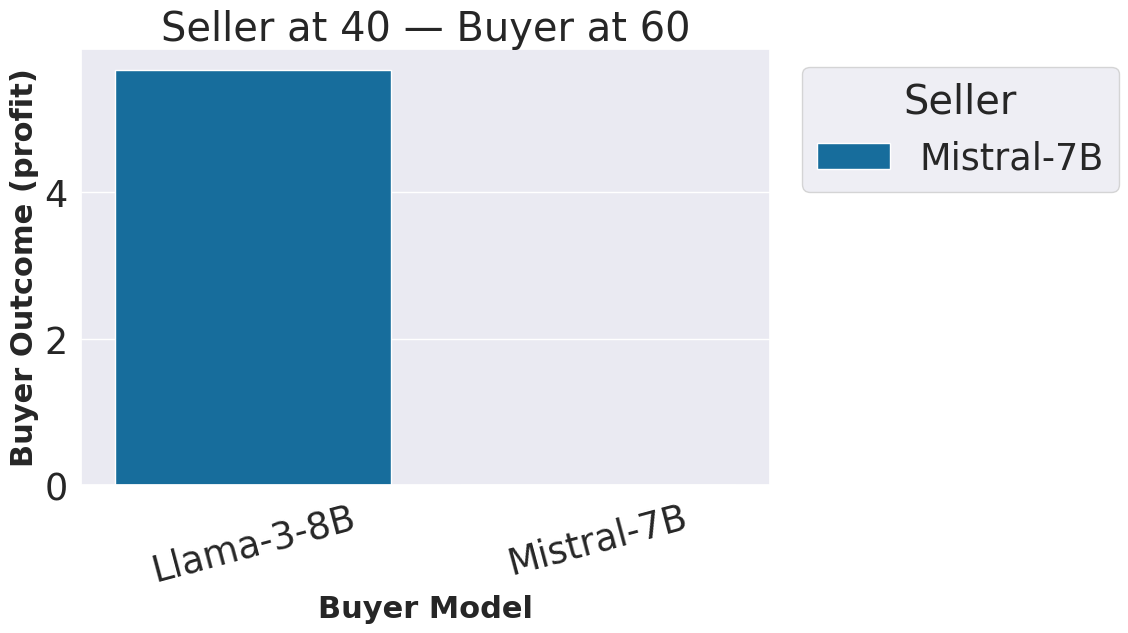

    seller      buyer  outcome_mean  outcome_sem  n
Mistral-7B Llama-3-8B      5.666667     5.666667  3
Mistral-7B Mistral-7B      0.000000     0.000000  7


In [17]:
# Filter out broken games where outcomes exceed valid range
# Max buyer profit is 60 (buys at 0 with valuation 60), min is -100 (pays 100 for item worth 60)
valid = seller_at_40[(seller_at_40["outcome_2"] >= -100) & (seller_at_40["outcome_2"] <= 60)]
print(f"Filtered {len(seller_at_40) - len(valid)} outlier games")

agg = valid.groupby(["model_1", "model_2"])["outcome_2"].agg(["mean", "sem", "count"]).reset_index()
agg.columns = ["seller", "buyer", "outcome_mean", "outcome_sem", "n"]
agg = agg[agg["n"] >= 2]

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(data=agg, x="buyer", y="outcome_mean", hue="seller",
            palette="colorblind", capsize=0.1, ax=ax)

ax.set_ylabel("Buyer Outcome (profit)", fontdict=dict(weight="bold", size=22))
ax.set_xlabel("Buyer Model", fontdict=dict(weight="bold", size=22))
ax.set_title("Seller at 40 — Buyer at 60")
ax.legend(title="Seller", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig("../figures/oss_seller_at_40.pdf", bbox_inches="tight")
plt.show()

print(agg.to_string(index=False))